<a href="https://colab.research.google.com/github/Aadi2612/urban-rural-erosion-prediction/blob/main/Rural_ml_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Rural Model ML Prediction


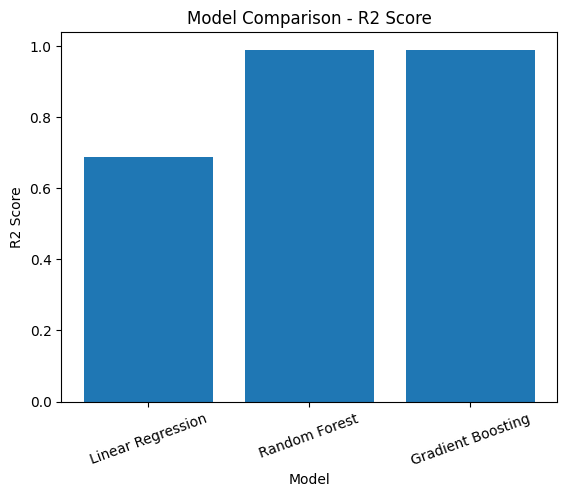

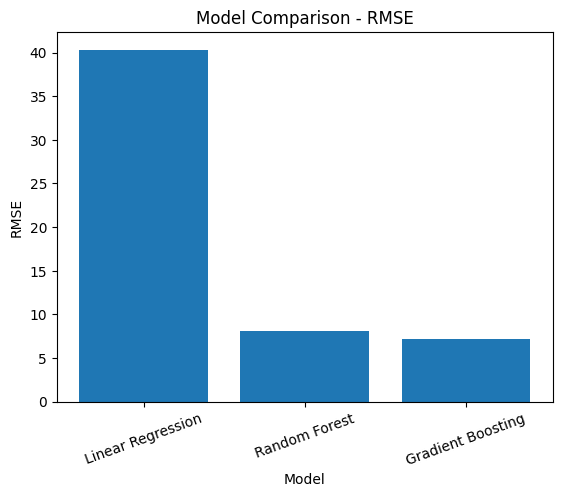

Best Model Selected: Gradient Boosting
                  Feature  Importance
7               lulc_250m    0.543288
1           rainfall_250m    0.291780
4     thanjavur_ndvi_250m    0.083709
2  thanjavur_kfactor_250m    0.075210
8              slope_250m    0.005380
0       thanjavur_dem_250    0.000315
5     sand_thanjavur_250m    0.000186
3      soil_moisture_250m    0.000097
6     clay_thanjavur_250m    0.000035


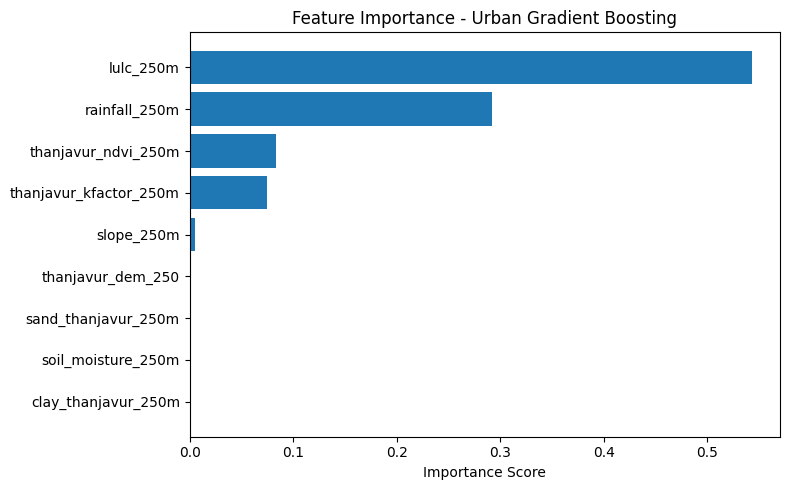

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error

df = pd.read_csv("thanjavur_ml.csv")

df.head()

#define features
features = [
    "thanjavur_dem_250",
    "rainfall_250m",
    "thanjavur_kfactor_250m",
    "soil_moisture_250m",
    "thanjavur_ndvi_250m",
    "sand_thanjavur_250m",
    "clay_thanjavur_250m",
    "lulc_250m",
    "slope_250m"
]

#creating feature matrix
X = df[features]
#defining target matrix
y = df["soil_loss_thanjavur"]
#creating test train split(80% training , 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
#using 3 models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = []
#training each model one by one initially and getting predictions
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    #got the r2 score of that model
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    #got the rmse of the model

    results.append([name, r2, rmse])
#created a dataframe for comparison
results_df = pd.DataFrame(results, columns=["Model", "R2 Score", "RMSE"])
results_df

#plotting R2 scores
plt.figure()
plt.bar(results_df["Model"], results_df["R2 Score"])
plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.title("Model Comparison - R2 Score")
plt.xticks(rotation=20)
plt.show()

#plotting RMSE scores
plt.figure()
plt.bar(results_df["Model"], results_df["RMSE"])
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title("Model Comparison - RMSE")
plt.xticks(rotation=20)
plt.show()

#choosing best model on the basis of R2 score
best_model_name = results_df.sort_values("R2 Score", ascending=False).iloc[0]["Model"]
best_model = models[best_model_name]

print("Best Model Selected:", best_model_name)
#using the best chosen model to train all the data
best_model.fit(X, y)
#creating a new column of predicted output score
df["soil_loss_pred"] = best_model.predict(X)

output = df[["fid", "soil_loss_pred"]]

output.to_csv("thanjavur_predictions.csv", index=False)

# Save model
joblib.dump(model, "rural_gradient_boosting.pkl")

# Feature importance
importance = model.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(importance_df)

# Plot
plt.figure(figsize=(8,5))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance - Urban Gradient Boosting")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("urban_feature_importance.png")
plt.show()